In [78]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [79]:
import pandas as pd

In [80]:
file_path="penguins_size.csv"

#To read csv file
df=pd.read_csv(file_path)

In [81]:
#handling missing values using ==
df["culmen_length_mm"].isna().sum()

np.int64(2)

In [82]:
df["culmen_length_mm"].mean()
df.columns

Index(['species', 'island', 'culmen_length_mm', 'culmen_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='str')

In [83]:
columns=['culmen_depth_mm', 'flipper_length_mm','body_mass_g']
df.columns

Index(['species', 'island', 'culmen_length_mm', 'culmen_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='str')

In [84]:
df[columns]=df[columns].fillna(df[columns].mean())

In [85]:
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.70000,181.000000,3750.000000,MALE
1,Adelie,Torgersen,39.5,17.40000,186.000000,3800.000000,FEMALE
2,Adelie,Torgersen,40.3,18.00000,195.000000,3250.000000,FEMALE
3,Adelie,Torgersen,NaN,17.15117,200.915205,4201.754386,NaN
4,Adelie,Torgersen,36.7,19.30000,193.000000,3450.000000,FEMALE


In [86]:
#filling missing values
df["culmen_length_mm"]=df["culmen_length_mm"].fillna(df["culmen_length_mm"].mean()) #single column
df

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.10000,18.70000,181.000000,3750.000000,MALE
1,Adelie,Torgersen,39.50000,17.40000,186.000000,3800.000000,FEMALE
2,Adelie,Torgersen,40.30000,18.00000,195.000000,3250.000000,FEMALE
3,Adelie,Torgersen,43.92193,17.15117,200.915205,4201.754386,NaN
4,Adelie,Torgersen,36.70000,19.30000,193.000000,3450.000000,FEMALE
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,43.92193,17.15117,200.915205,4201.754386,NaN
340,Gentoo,Biscoe,46.80000,14.30000,215.000000,4850.000000,FEMALE
341,Gentoo,Biscoe,50.40000,15.70000,222.000000,5750.000000,MALE
342,Gentoo,Biscoe,45.20000,14.80000,212.000000,5200.000000,FEMALE


In [87]:
# Handling missing values in text 
mass_median=df.groupby(['species','sex'])["body_mass_g"].median()
mass_median["Adelie"]["FEMALE"]
mass_median

species    sex   
Adelie     FEMALE    3400.0
           MALE      4000.0
Chinstrap  FEMALE    3550.0
           MALE      3950.0
Gentoo     .         4875.0
           FEMALE    4700.0
           MALE      5500.0
Name: body_mass_g, dtype: float64

In [88]:
df["species"]

0      Adelie
1      Adelie
2      Adelie
3      Adelie
4      Adelie
        ...  
339    Gentoo
340    Gentoo
341    Gentoo
342    Gentoo
343    Gentoo
Name: species, Length: 344, dtype: str

In [89]:
def fill_empty(row):
    spec=row["species"]

    try:
        male_mass_median=mass_median[spec]["MALE"]
        male_mass_median

        female_mass_median=mass_median[spec]["FEMALE"]
        female_mass_median

    except:
        return "MALE"

    threshold=(male_mass_median+female_mass_median)/2
    threshold

    if row["body_mass_g"]>=threshold:
        return "MALE"
    else:
        return  "FEMALE"

In [90]:
mask_gender=(df["sex"].isna()) | (df["sex"]==".")
mask_gender.sum()

np.int64(11)

In [91]:
df.loc[mask_gender,"sex"]=df[mask_gender].apply(fill_empty,axis=1)

In [92]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


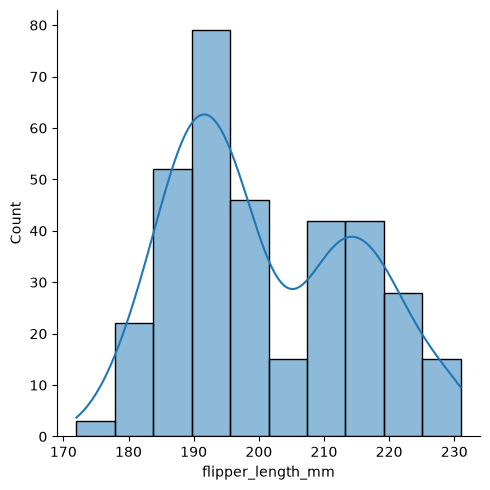

In [93]:
import seaborn as sns

sns.displot(df["flipper_length_mm"],kde = True)

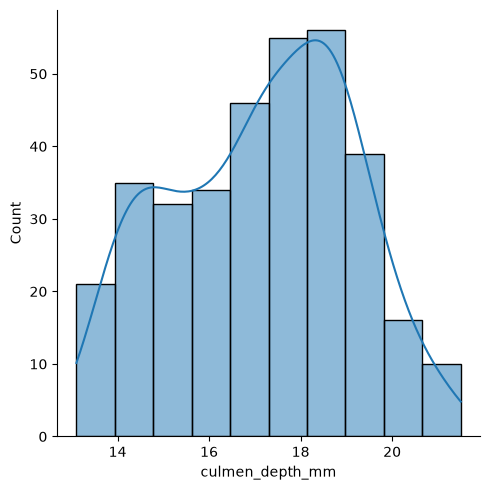

In [94]:
sns.displot(df["culmen_depth_mm"],kde=True)

In [95]:
# count
a=df["species"].value_counts()
a

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

In [96]:
df.columns

Index(['species', 'island', 'culmen_length_mm', 'culmen_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='str')

In [97]:
#Correlation - only numerical data
numerical_col = ['culmen_length_mm', 'culmen_depth_mm','flipper_length_mm', 'body_mass_g']
corr_matrix = df[numerical_col].corr()
corr_matrix

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
culmen_length_mm,1.000000,-0.235053,0.656181,0.595110
culmen_depth_mm,-0.235053,1.000000,-0.583851,-0.471916
flipper_length_mm,0.656181,-0.583851,1.000000,0.871202
body_mass_g,0.595110,-0.471916,0.871202,1.000000


<Axes: >

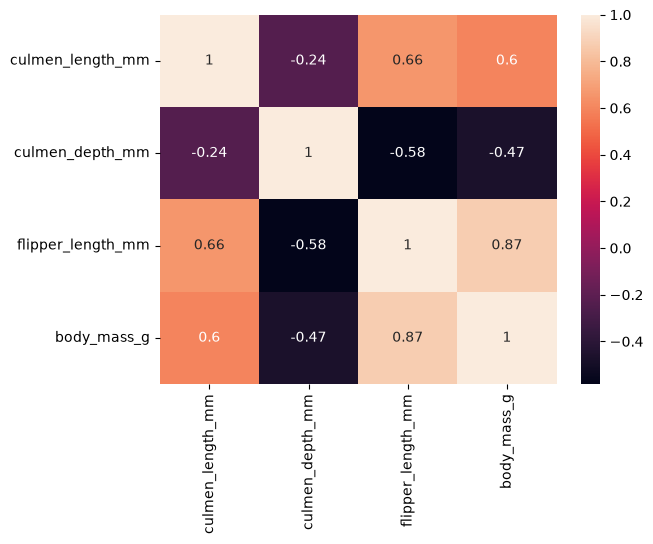

In [98]:
sns.heatmap(corr_matrix,annot=True) #annot displays the values

In [99]:
df["culmen_ratio"] = df["culmen_length_mm"] / df["culmen_depth_mm"]

In [100]:
#Catagorical to numerical
#1 - Mapping
gender_map={
    "Male":0,
    "Female":1
}

df["encoded_sex"]=df["sex"].map(gender_map)
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex,culmen_ratio,encoded_sex
0,Adelie,Torgersen,39.10000,18.70000,181.000000,3750.000000,MALE,2.090909,NaN
1,Adelie,Torgersen,39.50000,17.40000,186.000000,3800.000000,FEMALE,2.270115,NaN
2,Adelie,Torgersen,40.30000,18.00000,195.000000,3250.000000,FEMALE,2.238889,NaN
3,Adelie,Torgersen,43.92193,17.15117,200.915205,4201.754386,MALE,2.560871,NaN
4,Adelie,Torgersen,36.70000,19.30000,193.000000,3450.000000,FEMALE,1.901554,NaN


<Axes: >

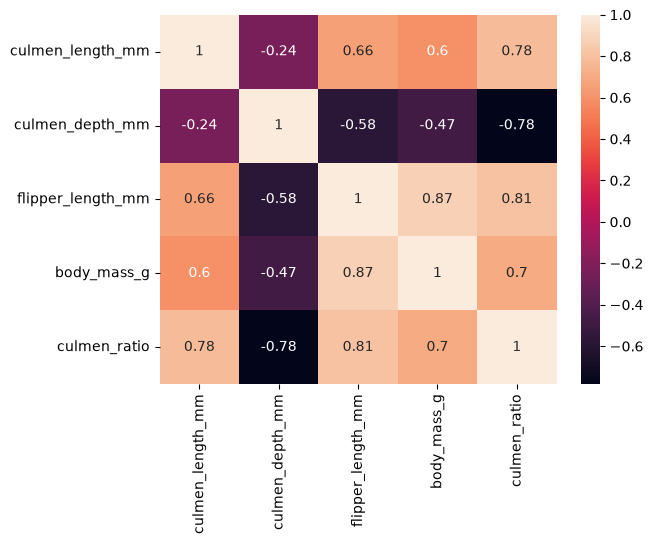

In [101]:
# Correlation
numerical_col = ['culmen_length_mm', 'culmen_depth_mm','flipper_length_mm', 'body_mass_g','culmen_ratio']
corr_matrix = df[numerical_col].corr()
sns.heatmap(corr_matrix,annot=  True)

In [102]:
# pd.get_dummies(df,columns=["island"],dtype=int)

pd.get_dummies(df,columns=["island"],dtype=int,drop_first=True)
df

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex,culmen_ratio,encoded_sex
0,Adelie,Torgersen,39.10000,18.70000,181.000000,3750.000000,MALE,2.090909,NaN
1,Adelie,Torgersen,39.50000,17.40000,186.000000,3800.000000,FEMALE,2.270115,NaN
2,Adelie,Torgersen,40.30000,18.00000,195.000000,3250.000000,FEMALE,2.238889,NaN
3,Adelie,Torgersen,43.92193,17.15117,200.915205,4201.754386,MALE,2.560871,NaN
4,Adelie,Torgersen,36.70000,19.30000,193.000000,3450.000000,FEMALE,1.901554,NaN
...,...,...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,43.92193,17.15117,200.915205,4201.754386,FEMALE,2.560871,NaN
340,Gentoo,Biscoe,46.80000,14.30000,215.000000,4850.000000,FEMALE,3.272727,NaN
341,Gentoo,Biscoe,50.40000,15.70000,222.000000,5750.000000,MALE,3.210191,NaN
342,Gentoo,Biscoe,45.20000,14.80000,212.000000,5200.000000,FEMALE,3.054054,NaN


In [103]:
# mapping

gender_map = {
    "MALE":0,
    "FEMALE":1
}
df["encoded_sex"]= df["sex"].map(gender_map)
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex,culmen_ratio,encoded_sex
0,Adelie,Torgersen,39.10000,18.70000,181.000000,3750.000000,MALE,2.090909,0
1,Adelie,Torgersen,39.50000,17.40000,186.000000,3800.000000,FEMALE,2.270115,1
2,Adelie,Torgersen,40.30000,18.00000,195.000000,3250.000000,FEMALE,2.238889,1
3,Adelie,Torgersen,43.92193,17.15117,200.915205,4201.754386,MALE,2.560871,0
4,Adelie,Torgersen,36.70000,19.30000,193.000000,3450.000000,FEMALE,1.901554,1


In [104]:
df = pd.get_dummies(df,columns = ["island"],dtype = int)
df

,species,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex,culmen_ratio,encoded_sex,island_Biscoe,island_Dream,island_Torgersen
0,Adelie,39.10000,18.70000,181.000000,3750.000000,MALE,2.090909,0,0,0,1
1,Adelie,39.50000,17.40000,186.000000,3800.000000,FEMALE,2.270115,1,0,0,1
2,Adelie,40.30000,18.00000,195.000000,3250.000000,FEMALE,2.238889,1,0,0,1
3,Adelie,43.92193,17.15117,200.915205,4201.754386,MALE,2.560871,0,0,0,1
4,Adelie,36.70000,19.30000,193.000000,3450.000000,FEMALE,1.901554,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
339,Gentoo,43.92193,17.15117,200.915205,4201.754386,FEMALE,2.560871,1,1,0,0
340,Gentoo,46.80000,14.30000,215.000000,4850.000000,FEMALE,3.272727,1,1,0,0
341,Gentoo,50.40000,15.70000,222.000000,5750.000000,MALE,3.210191,0,1,0,0
342,Gentoo,45.20000,14.80000,212.000000,5200.000000,FEMALE,3.054054,1,1,0,0


In [105]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False,dtype = int)
encoded = encoder.fit_transform(df[["species"]])
df[encoder.get_feature_names_out()] = encoded
df.head()

,species,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex,culmen_ratio,encoded_sex,island_Biscoe,island_Dream,island_Torgersen,species_Adelie,species_Chinstrap,species_Gentoo
0,Adelie,39.10000,18.70000,181.000000,3750.000000,MALE,2.090909,0,0,0,1,1,0,0
1,Adelie,39.50000,17.40000,186.000000,3800.000000,FEMALE,2.270115,1,0,0,1,1,0,0
2,Adelie,40.30000,18.00000,195.000000,3250.000000,FEMALE,2.238889,1,0,0,1,1,0,0
3,Adelie,43.92193,17.15117,200.915205,4201.754386,MALE,2.560871,0,0,0,1,1,0,0
4,Adelie,36.70000,19.30000,193.000000,3450.000000,FEMALE,1.901554,1,0,0,1,1,0,0


In [106]:
df[encoder.get_feature_names_out()]=encoded

In [107]:
# df=df.drop(columns=["sex","species"],inplace=True)
# df

In [108]:
print(type(df))

<class 'pandas.DataFrame'>


In [111]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df["culmen_length_mm"] = scaler.fit_transform(df[['culmen_length_mm']])
df.head()

,species,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex,culmen_ratio,encoded_sex,island_Biscoe,island_Dream,island_Torgersen,species_Adelie,species_Chinstrap,species_Gentoo
0,Adelie,0.254545,18.70000,181.000000,3750.000000,MALE,2.090909,0,0,0,1,1,0,0
1,Adelie,0.269091,17.40000,186.000000,3800.000000,FEMALE,2.270115,1,0,0,1,1,0,0
2,Adelie,0.298182,18.00000,195.000000,3250.000000,FEMALE,2.238889,1,0,0,1,1,0,0
3,Adelie,0.429888,17.15117,200.915205,4201.754386,MALE,2.560871,0,0,0,1,1,0,0
4,Adelie,0.167273,19.30000,193.000000,3450.000000,FEMALE,1.901554,1,0,0,1,1,0,0


In [114]:
numeric_cols = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']

scaler = MinMaxScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

df.head()

,species,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex,culmen_ratio,encoded_sex,island_Biscoe,island_Dream,island_Torgersen,species_Adelie,species_Chinstrap,species_Gentoo
0,Adelie,0.254545,0.666667,0.152542,0.291667,MALE,2.090909,0,0,0,1,1,0,0
1,Adelie,0.269091,0.511905,0.237288,0.305556,FEMALE,2.270115,1,0,0,1,1,0,0
2,Adelie,0.298182,0.583333,0.389831,0.152778,FEMALE,2.238889,1,0,0,1,1,0,0
3,Adelie,0.429888,0.482282,0.490088,0.417154,MALE,2.560871,0,0,0,1,1,0,0
4,Adelie,0.167273,0.738095,0.355932,0.208333,FEMALE,1.901554,1,0,0,1,1,0,0
